# Marketing and Statistical Analysis Case Study

In [1]:
# Import modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr



In [2]:
# Import data

customers = pd.read_csv("data/customers.csv")
transactions = pd.read_csv("data/transactions.csv")
sessions = pd.read_csv("data/web_sessions.csv")
campaigns = pd.read_csv("data/marketing_campaigns.csv")

# Marketing Performance

### How effective are our marketing channels at driving revenue and conversions, and where should we invest to maximize growth?

Executive Summary

This project analyzes customer, transaction, and session-level data to evaluate marketing channel performance, customer behavior, and revenue drivers.

The objective was to determine:

Which acquisition channels generate the most revenue

How efficiently traffic converts into customers

Which customer segments drive the highest value

Where the greatest growth opportunities exist

The analysis reveals that revenue is primarily volume-driven, conversion rates are stable across channels, and significant revenue growth could be 
unlocked through funnel optimization and targeted segmentation strategies.

### Revenue Performance

Q1: Which are the total revenue by year?

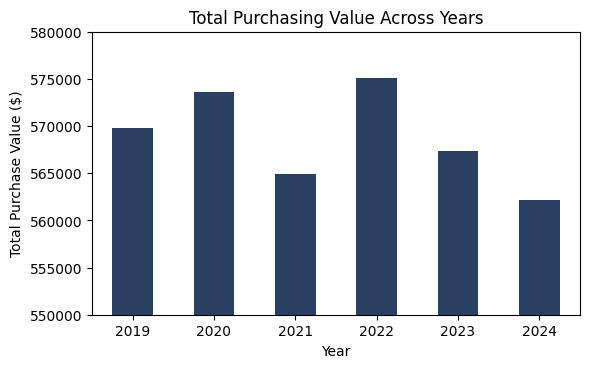

In [3]:
merged_tc = pd.merge(customers, transactions, on='customer_id', how='left')

#Ensure 'purchase_date' is in the correct datetime format
transactions['purchase_date'] = pd.to_datetime(transactions['purchase_date'])

#Extract the year into a new column
transactions['purchase_year'] = transactions['purchase_date'].dt.year

#Group by the year and sum the purchase values
yearly_sales = transactions.groupby('purchase_year')['purchase_value'].sum()

#Create the plot
yearly_sales.plot(kind='bar',color ='#2a4063', figsize=(6,4))

plt.style.use('seaborn-v0_8-deep')
plt.ylim(550000, 580000) 
plt.title('Total Purchasing Value Across Years', fontsize=12)
plt.xlabel('Year',fontsize=10)
plt.ylabel('Total Purchase Value ($)',fontsize=10)
plt.tight_layout()
plt.xticks(rotation=0) 
 
plt.show()

Q2: Which are the total revenue by product category?

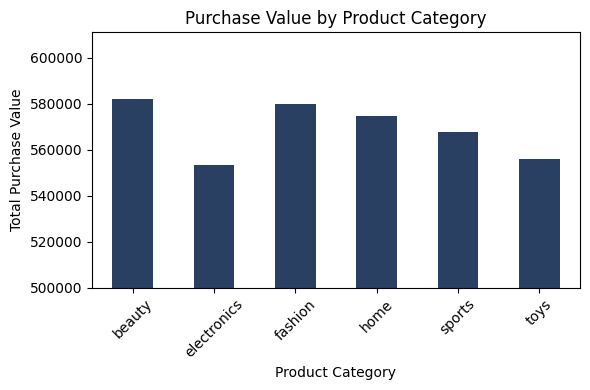

In [4]:
category_sales = transactions.groupby('product_category')['purchase_value'].sum()
category_sales.plot(kind='bar')

category_sales.plot(kind='bar', color ='#2a4063', figsize=(6,4))
plt.ylim(bottom = 500000)
plt.title('Purchase Value by Product Category',fontsize = 12)
plt.xlabel('Product Category', fontsize = 10)
plt.ylabel('Total Purchase Value', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Q3: Which marketing acquisition channels generate the most revenue?

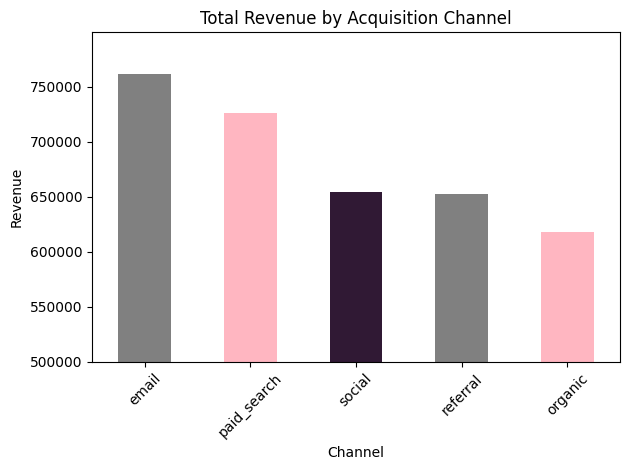

In [5]:
merged_tc['acquisition_channel'] = merged_tc['acquisition_channel'].str.lower()

channel_revenue = (
    merged_tc.groupby('acquisition_channel')['purchase_value']
    .sum()
    .sort_values(ascending=False)
)
my_colors = ['grey', '#FFB6C1', '#301934']
channel_revenue.plot(kind='bar',color= my_colors)
plt.ylim(bottom = 500000)
plt.title("Total Revenue by Acquisition Channel",fontsize=12)
plt.ylabel("Revenue",fontsize=10)
plt.xlabel("Channel",fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
print(channel_revenue)

acquisition_channel
email          761439.08
paid_search    726397.58
social         654061.49
referral       652936.94
organic        618086.59
Name: purchase_value, dtype: float64


### Conversion Efficiency


Q4: What is the percentage of converted and non-converted customers? 

In [7]:
#Calculate proportions (this gives values between 0 and 1)
conversion_proportions = sessions['converted'].value_counts(normalize=True)

#Multiply by 100 to get percentages
conversion_percentages = (conversion_proportions * 100).round(2)

#Rename index 
conversion_percentages.index = conversion_percentages.index.map({0: 'Non-Converted', 1: 'Converted'})
print(conversion_percentages)

converted
Non-Converted    86.91
Converted        13.09
Name: proportion, dtype: float64


<Axes: >

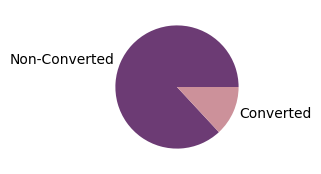

In [8]:
conversion_percentages.plot.pie(y=conversion_percentages, figsize = (4,2), colors= ['#6c3b74','#cc919a'])

Q5: Which traffic sources convert best?

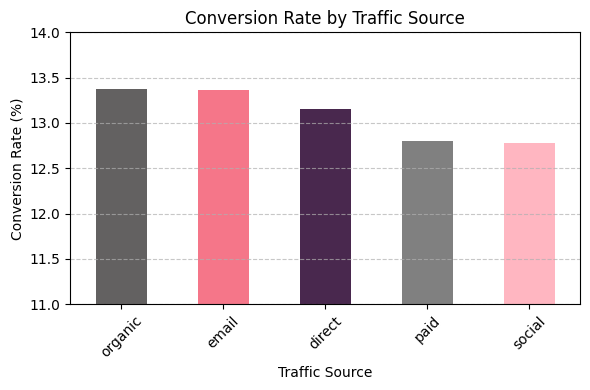

traffic_source
organic    13.38
email      13.36
direct     13.15
paid       12.80
social     12.78
Name: converted, dtype: float64


In [9]:
#Calculate the rate
conversion_rate = (
    sessions.groupby('traffic_source')['converted']
    .mean()
    .sort_values(ascending=False)
) * 100  
conversion_rate = conversion_rate.round(2)

#Create the plot
custom_colors = ["#636161FF", "#F57689", "#49284E", '#808080', '#FFB6C1']
conversion_rate.plot(kind='bar', figsize =(6,4), color= custom_colors)
plt.ylim(11, 14)
plt.title('Conversion Rate by Traffic Source', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=10)
plt.xlabel('Traffic Source', fontsize=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(conversion_rate)

### Customer Segmentation

Q6: Which customer segments generate the most value?

Creating age groups on customers and aggregate revenue by age group to identify trends

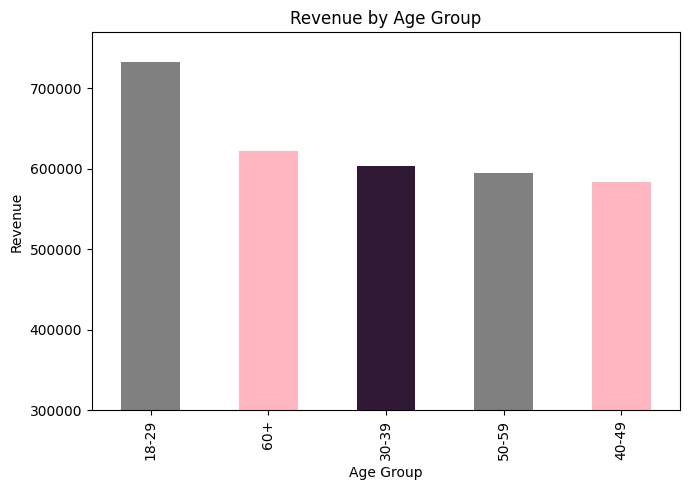

In [10]:
#create age groups on customers
bins = [18, 30, 40, 50, 60, 70]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)

#merge customers with transactions 
tc = transactions.merge(customers[['customer_id','age_group']], on='customer_id', how='left')

#aggregate revenue by age group
age_revenue = tc.groupby('age_group')['purchase_value'].sum().sort_values(ascending=False)

#plot
my_colors = ['grey', '#FFB6C1', '#301934']
age_revenue.plot(kind='bar', color=(my_colors),figsize=(7,5))
plt.ylim(bottom = 300000)
plt.title("Revenue by Age Group",fontsize=12)
plt.ylabel("Revenue",fontsize=10)
plt.xlabel("Age Group",fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
print(age_revenue)

age_group
18-29    732494.49
60+      622408.82
30-39    603508.38
50-59    594189.17
40-49    583202.35
Name: purchase_value, dtype: float64


Q7: What is the number of active customers by age group?

In [11]:
#Count unique IDs per age group 
active_customers = tc.groupby('age_group')['customer_id'].nunique().sort_values(ascending=False)

print(active_customers)

age_group
18-29    2095
60+      1787
30-39    1746
40-49    1733
50-59    1719
Name: customer_id, dtype: int64


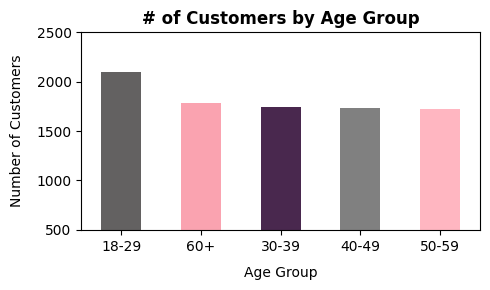

In [12]:
custom_colors = ["#636161", "#FAA3B0", "#49284E", '#808080', '#FFB6C1']

#Create Plot for # of customers
plt.figure(figsize=(5, 3))
active_customers.plot(kind='bar', color=custom_colors, linewidth=1)

plt.ylim(500, 2500)
plt.title("# of Customers by Age Group", fontsize=12, fontweight='bold')
plt.ylabel("Number of Customers", fontsize=10, labelpad=9)
plt.xlabel("Age Group", fontsize=10, labelpad=9)
plt.xticks(rotation=0) 
plt.tight_layout()

plt.show()

| Age Group | Revenue ($) | Active Customers |
| --------- | ----------- | ---------------- |
| 18–29     | 732,494     | 2,095            |
| 60+       | 622,409     | 1,787            |
| 30–39     | 603,508     | 1,746            |
| 50–59     | 594,189     | 1,719            |
| 40–49     | 583,202     | 1,733            |


Q8: What is the average revenue per age group?

In [13]:
revenue_per_customer = age_revenue / active_customers
revenue_per_customer = revenue_per_customer.round(2)
print(revenue_per_customer)

age_group
18-29    349.64
30-39    345.65
40-49    336.53
50-59    345.66
60+      348.30
dtype: float64


### Customer Engagement & Purchase Behavior

Q9: Do purchasing customers behave differently on-site?

In [14]:
#total time per customer
time_per_customer = sessions.groupby(['customer_id','converted'])['time_on_site'].sum().reset_index()

#average per segment
avg_time = time_per_customer.groupby('converted')['time_on_site'].mean()

avg_converted = avg_time.loc[1]
avg_non_converted = avg_time.loc[0]

print(f"Purchasing customers spent on site {avg_converted:.2f} seconds on average, while non-purchasing customers spent {avg_non_converted:.2f} seconds on average")

Purchasing customers spent on site 475.13 seconds on average, while non-purchasing customers spent 1827.56 seconds on average


Q10: Which is the average number of pages viewed for customers who made a purchase?

In [15]:
converted_sessions = sessions[sessions['converted'] == 1]

#total page views per customer
pages_per_customer = converted_sessions.groupby('customer_id')['pages_viewed'].sum()

#average across customers
avg_pages_converted = pages_per_customer.mean()

non_converted_sessions = sessions[sessions['converted'] == 0]

#total page views per customer
pages_per_nonconverted = non_converted_sessions.groupby('customer_id')['pages_viewed'].sum()

#average across customers
avg_pages_nonconverted = pages_per_nonconverted.mean()


print(f"The average number of pages viewed for customers who made a purchase is {avg_pages_converted:.2f} and the average number of pages viewed of non-converted is {avg_pages_nonconverted: .2f}")

The average number of pages viewed for customers who made a purchase is 8.75 and the average number of pages viewed of non-converted is  29.84


| Metric            | Converted | Non-Converted |
| ----------------- | --------- | ------------- |
| Avg. Time on Site | 475 sec   | 1828 sec      |
| Avg. Pages Viewed | 8.75      | 29.84       |


Insights:
1. Email generates the highest total revenue, indicating strong customer responsiveness to direct communication campaigns. 
This suggests that expanding email segmentation or automation workflows could yield incremental revenue without increasing paid acquisition costs.

2. The 18-29 segment drives the most revenue primarily due to volume rather than higher individual spending. 
This indicates acquisition success in younger audiences but highlights an opportunity to increase average order value through 
bundling or upselling strategies. 

3. With nearly 87% of sessions currently resulting in no purchase, there is a massive opportunity to scale revenue by identifying
and removing the friction points that prevent this vast majority of users from converting.
Even an 1% increase in conversion rate could significantly increase total revenue. 
Funnel optimization initiatives (checkout simplification, personalized recommendations) represent a high-impact growth lever.

4. Conversion rates are remarkably consistent across all traffic sources (≈13%), suggesting that the website's ability to convert visitors is largely independent of acquisition channel. 
Marketing efforts should prioritize traffic scale and cost efficiency rather than reallocating based on conversion quality.


5. Purchasing customers spend significantly less time on the site than non-purchasers, suggesting high-intent behavior.
Non-converting users may be browsing without clear purchase intent, indicating an opportunity to implement stronger call-to-action triggers or 
personalized recommendations.

# Statistical Business Analysis

Executive Summary:
This chapter also analyzes customer, transaction, and session-level data to evaluate marketing channel performance, customer behavior, and revenue drivers through Hypothesis testing and correlations.

The objective was to determine:

Whether there is a significant difference between discounted and non-discounted purchases

Demographic differences

If there are differences between transactions and acquisition channels or device types

The relationship between the purchase value and time-on-site or pages viewed

Customer behaviour regarding session time and convertion rate

The  statistical analysis reveals that the marketing budget should be based on a combination of performance metrics, investing not only in sources with high conversion rates but also in those that attract customers with higher average purchase value, in order to maximize total revenue and profitability.

## Main Hypothesis tests that attribute to business insights

Q1. Do discounted purchases differ in average value from non-discounted purchases?

Ho (Null Hypothesis): There is no difference in average purchase value between discounted and non-discounted purchases.

H1 (Alternative Hypothesis): There is a differense

In [16]:
discounted = transactions[transactions["discount_used"] == 1]["purchase_value"]
non_discounted = transactions[transactions["discount_used"] == 0]["purchase_value"]
print(discounted.mean().round(2))
print(non_discounted.mean().round(2))

t_stat, p_value = ttest_ind(
    discounted,
    non_discounted,
    equal_var=False  
)

print(f"T-statistic: {t_stat: .3f}") 
print(f"P-Value: {p_value: .5f}")

#Interpret the result
alpha = 0.05 
if p_value < alpha:
    print("Reject the Null Hypothesis: There is difference in avg purchase value between discounted and non-discounted purchases.")
else:
    print("Fail to Reject the Null Hypothesis: No significant difference found.")

64.4
80.76
T-statistic: -29.982
P-Value:  0.00000
Reject the Null Hypothesis: There is difference in avg purchase value between discounted and non-discounted purchases.


The difference is highly statistically significant.

Business Meaning: While discounts lower the average transaction value, they still play an important role in customer acquisition. The business challenge is to balance discount-driven volume with revenue quality by targeting promotions strategically across marketing channels.

Q2. Do male and female customers differ in average purchase value?

Ho (Null Hypothesis): There is no difference in avarage purchase value between  male and female customers.

H1 (Alternative Hypothesis): There is a differense

In [17]:
# merge Transactions with Customers table
df_merged = transactions.merge(customers, on='customer_id')
male = df_merged[df_merged["gender"] == "Male"]["purchase_value"]
female = df_merged[df_merged["gender"] == "Female"]["purchase_value"]

t_stat, p_value = ttest_ind(
    male,
    female,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.5f}")

#Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis. There is no statistically significant evidence to suggest that purchase value differs by gender.")

print("Mean Male:", male.mean().round(2))
print("Mean Female:", female.mean().round(2))

T-statistic: 1.0825
P-value: 0.27903
Fail to reject the null hypothesis. There is no statistically significant evidence to suggest that purchase value differs by gender.
Mean Male: 76.04
Mean Female: 75.31


Q3. Do customers acquired via email spend more than those from social channels? 

Ho (Null Hypothesis): There is no difference in spending between customers via email and social channels.

H1 (Alternative Hypothesis): There is a differense in spending.

In [18]:
email = df_merged[df_merged["acquisition_channel"] == "email"]["purchase_value"]
social = df_merged[df_merged["acquisition_channel"] == "social"]["purchase_value"]

t_stat, p_value = ttest_ind(email, social, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis, there isn't significant difference.")

print("Mean spending via email:", email.mean().round(2))
print("Mean spending via social:", social.mean().round(2))

T-statistic: -0.6976
P-value: 0.48546
Fail to reject the null hypothesis, there isn't significant difference.
Mean spending via email: 75.43
Mean spending via social: 76.04


Q4. Is device type associated with conversion?

If p < 0,05 - device type and conversion are related

If p > 0,05 - no strong evidence of relationship

Ho: Device type and conversion are independent (no relationship).

H1: Device type and conversion are associated.

In [19]:
contingency_table = pd.crosstab(sessions['device_type'], sessions['converted'])

print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("Reject Ho: Device type and conversion are related.")
else:
    print("Fail to reject Ho: No strong evidence of relationship.")

converted        0     1
device_type             
desktop      20020  3068
mobile       20213  3042
tablet       20244  3013
Chi-square statistic: 1.1502
P-value: 0.56265
Fail to reject Ho: No strong evidence of relationship.


Q5. Is acquisition channel associated with conversion?

If p < 0,05 - acquisition channel and conversion are related

If p > 0,05 - no strong evidence of relationship

H₀: Acquisition channel and conversion are independent.

H1: Acquisition channel and conversion are associated.

In [20]:
sc_merged = sessions.merge(customers, on="customer_id")

sc_merged["acquisition_channel"] = (
    sc_merged["acquisition_channel"]
    .str.lower()
    .str.strip()
)
  
contingency_table = pd.crosstab(
    sc_merged["acquisition_channel"],
    sc_merged["converted"]
)

print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05

if p_value < alpha:
    print("Reject Ho:Acquisition channel and conversion are related.")
else:
    print("Fail to reject Ho: Acquisition channel and conversion are independent.")

converted                0     1
acquisition_channel             
email                13525  2048
organic              11079  1673
paid_search          13209  1914
referral             11563  1746
social               11545  1798
Chi-square statistic: 4.3101
P-value: 0.36566
Fail to reject Ho: Acquisition channel and conversion are independent.


Q6. Is product category associated with discount usage?

If p < 0,05 - product category and discount are related

If p > 0,05 - no strong evidence of relationship

H₀: Product category and discount are independent.

H1: Product category and discount are associated.

In [21]:
contingency_table = pd.crosstab(transactions['product_category'], transactions['discount_used'])
print("Contingency Table:\n", contingency_table)

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi2 statistic: {chi2:.4f}")
print(f"P-value: {p_value:.5f}")

# Interpret the result
alpha = 0.05

if p_value < alpha:
    print("Reject Ho: Product category and discount usage are associated.")
else:
    print("Fail to reject Ho: No strong evidence of association between product category and discount.")

Contingency Table:
 discount_used        0     1
product_category            
beauty            5305  2281
electronics       5212  2212
fashion           5326  2255
home              5210  2278
sports            5225  2279
toys              5196  2221

Chi2 statistic: 1.4622
P-value: 0.91739
Fail to reject Ho: No strong evidence of association between product category and discount.


Q7. Is time on site correlated with purchase value?

H0: There is no linear correlation between time on site and purchase value p = 0

H1: There is a linear correlation between time on site and purchase value p ≠ 0

In [22]:
# Aggregate spending per customer
total_spending = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()

# Aggregate time per customer 
avg_time = sessions.groupby('customer_id')['time_on_site'].mean().reset_index()

# Merge the aggregated data
customer_data = total_spending.merge(avg_time, on='customer_id')

# Correlation
pearson_corr, pearson_p = pearsonr(customer_data['time_on_site'], customer_data['purchase_value'])


print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"P-value: {pearson_p:.3f}")

alpha = 0.05
if pearson_p < alpha:
    print("Time on site and purchase value are correlated.")
else:
    print("No strong evidence of correlation between time on site and purchase value.")


Pearson correlation: 0.003
P-value: 0.771
No strong evidence of correlation between time on site and purchase value.


Business Meaning: Customers spending more time on site does not appear to be associated with higher (or lower) purchase values.

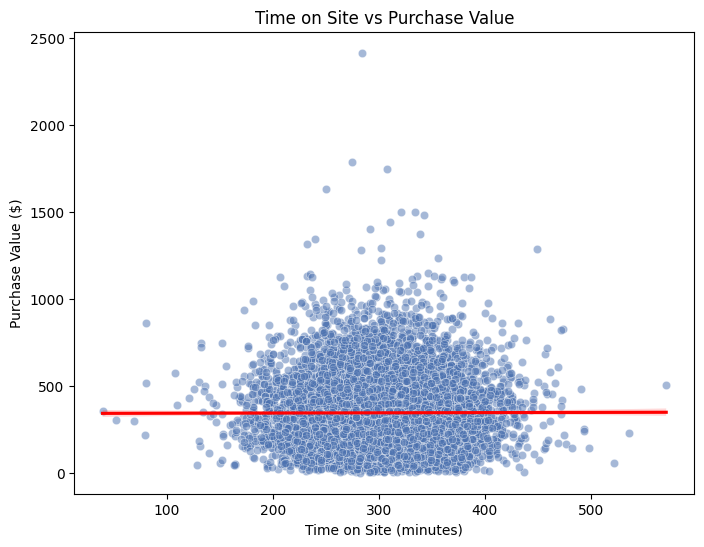

In [23]:
# scatter plot with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(data=customer_data, x='time_on_site', y='purchase_value', alpha=0.5)
sns.regplot(data=customer_data, x='time_on_site', y='purchase_value', scatter=False, color='red')
plt.title('Time on Site vs Purchase Value')
plt.xlabel('Time on Site (minutes)')
plt.ylabel('Purchase Value ($)')
plt.show()

Q8. Is number of pages viewed correlated with purchase value?

Ho: There is no linear correlation between pages viewed and purchase value (ρ = 0)

H1 = There is a linear correlation between pages viewed and purchase value (ρ ≠ 0)

In [24]:
# Aggregate total spending per customer
total_spending = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()

# Aggregate average pages viewed per customer
avg_pages = sessions.groupby('customer_id')['pages_viewed'].mean().reset_index()

# Merge aggregated data
customer_data = total_spending.merge(avg_pages, on='customer_id')

# Rename for clarity 
customer_data.columns = ['customer_id', 'total_spending', 'avg_pages_viewed']

# Pearson correlation
pearson_corr, pearson_p = pearsonr(
    customer_data['avg_pages_viewed'],
    customer_data['total_spending']
)

print(f"Pearson correlation coefficient: {pearson_corr:.5f}")
print(f"P-value: {pearson_p:.5f}")

alpha = 0.05
if pearson_p < alpha:
    print("Conclusion: Reject H0 → There is a statistically significant correlation.")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation.")

Pearson correlation coefficient: 0.00044
P-value: 0.96552
Conclusion: Fail to reject H0 → No significant correlation.


Q9. Is time on site correlated with pages viewed?

H0: There is no linear correlation between time on site and pages viewed (ρ = 0)

H1: There is a linear correlation between time on site and pages viewed (ρ ≠ 0)

Pearson correlation coefficient: 0.005
P-value: 0.229
Conclusion: Fail to reject H0 → No significant correlation between time on site and pages viewed.


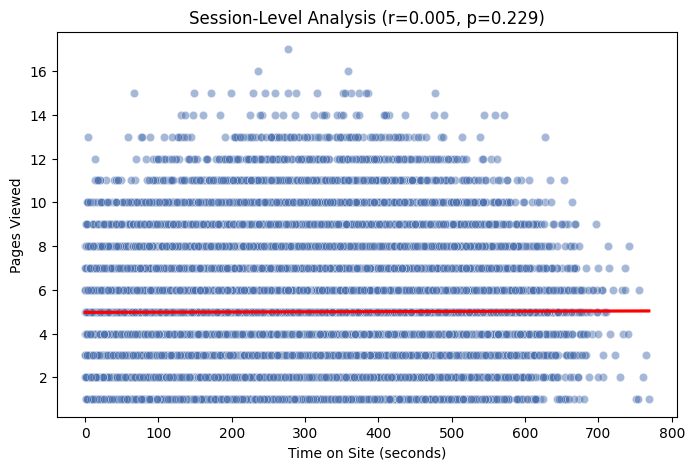

In [25]:
#session level
pearson_corr, pearson_p = pearsonr(sessions['time_on_site'], sessions['pages_viewed'])
print(f"Pearson correlation coefficient: {pearson_corr:.3f}")
print(f"P-value: {pearson_p:.3f}")

alpha = 0.05
if pearson_p < alpha:
    print("Conclusion: Reject H0 → Time on site and pages viewed are significantly correlated.")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation between time on site and pages viewed.")

# Visualize the session-level relationship
plt.figure(figsize=(8, 5))
sns.scatterplot(x='time_on_site', y='pages_viewed', data=sessions, alpha=0.5)
sns.regplot(x='time_on_site', y='pages_viewed', data=sessions, scatter=False, color='red')

plt.title(f'Session-Level Analysis (r={pearson_corr:.3f}, p={pearson_p:.3f})')
plt.xlabel('Time on Site (seconds)')
plt.ylabel('Pages Viewed')
plt.show()

The red line in the graph is almost completely flat. 

Business meaning: "Increasing the time a user spends on the site during a visit does not reliably increase the number of pages they look at."

Q10: Explore whether high-spending customers behave differently in terms of session time.

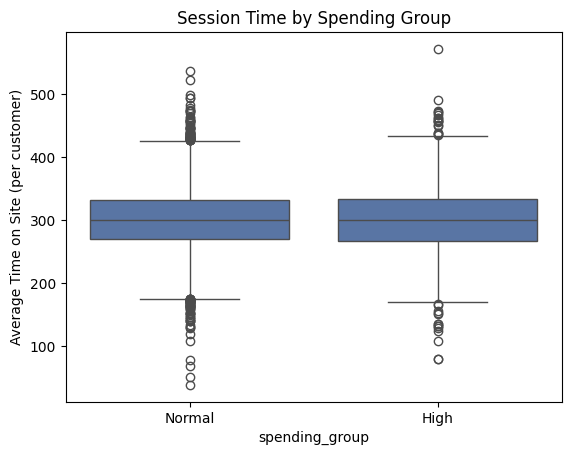

T-statistic: -0.1323
P-value: 0.89472
No strong evidence of difference


In [26]:
#Calculate total spending per customer 
total_spend = transactions.groupby('customer_id')['purchase_value'].sum().reset_index()

#Calculate average session time per customer 
avg_time = sessions.groupby('customer_id')['time_on_site'].mean().reset_index()

# merging the two summaries
customer_data = total_spend.merge(avg_time, on='customer_id')

#Defining High Spenders 
threshold = customer_data['purchase_value'].quantile(0.75)
customer_data['spending_group'] = customer_data['purchase_value'].apply(
    lambda x: 'High' if x >= threshold else 'Normal'
)
#T-Test 
high = customer_data[customer_data['spending_group'] == 'High']['time_on_site']
normal = customer_data[customer_data['spending_group'] == 'Normal']['time_on_site']
t_stat, p_value = ttest_ind(high, normal, equal_var=False)

#visual
sns.boxplot(x='spending_group', y='time_on_site', data=customer_data)
plt.title('Session Time by Spending Group')
plt.ylabel('Average Time on Site (per customer)')
plt.show()

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.5f}")

alpha = 0.05
if p_value < alpha:
    print("High spenders differ significantly from normal spenders")
else:
    print("No strong evidence of difference")



Q11: Conversion Rate vs Average Purchase Value

In [27]:
# Merge tables on customer_id
st_merged = sessions.merge(transactions, on="customer_id", how="left")
conversion_rate = (
    sessions
    .groupby("traffic_source")["converted"]
    .mean()
)

avg_purchase = (
    st_merged
    .groupby("traffic_source")["purchase_value"]
    .mean()
)

summary = pd.concat([conversion_rate, avg_purchase], axis=1)
summary.columns = ["conversion_rate", "avg_purchase"]

r = summary["conversion_rate"].corr(summary["avg_purchase"])
print("Pearson r:", r)

print(avg_purchase)

Pearson r: -0.38076210305445723
traffic_source
direct     75.887188
email      75.769243
organic    75.462965
paid       75.568400
social     76.021318
Name: purchase_value, dtype: float64


Examining the relationship between conversion rate and average purchase value across traffic sources is important
because traffic source reflects marketing campaigns that management can influence. The negative correlation shows that sources 
generating more conversions do not necessarily produce higher-spending customers. 

Business Meaning: This suggests that the marketing strategy should allocate the budget based on a combination of performance metrics, 
investing not only in sources with high conversion rates but also in those that attract customers with higher average purchase value, 
in order to maximize total revenue and profitability.

Q12: Correlation between Time on Site and Pages Viewed at customer level

H0: There is no linear correlation between time on site and pages viewed (ρ = 0)

H1: There is a linear correlation between time on site and pages viewed (ρ ≠ 0)

Pearson correlation coefficient: 0.847
P-value: 0.000
Conclusion: Reject H0 → Time on site and pages viewed are significantly correlated.


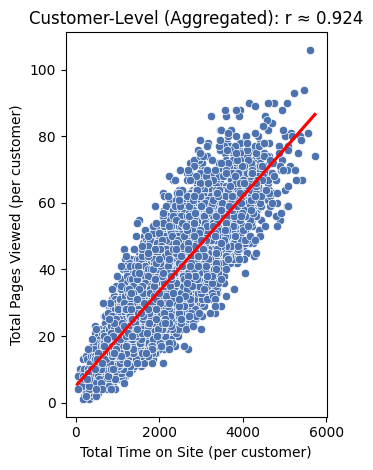

In [28]:
timeandpages_per_customer = sessions.groupby('customer_id').agg({
    'time_on_site': 'sum',     
    'pages_viewed': 'sum'      
}).reset_index()

pearson_corr, pearson_p = pearsonr(timeandpages_per_customer['time_on_site'], timeandpages_per_customer['pages_viewed'])
print(f"Pearson correlation coefficient: {pearson_corr:.3f}")
print(f"P-value: {pearson_p:.3f}")
alpha = 0.05
if pearson_p < alpha:
    print("Conclusion: Reject H0 → Time on site and pages viewed are significantly correlated.")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation between time on site and pages viewed.")

# scatter plot with regression line 
plt.subplot(1,2,2)
sns.scatterplot(
    x='time_on_site', 
    y='pages_viewed', 
    data=timeandpages_per_customer
)
# regression line
sns.regplot(
    x='time_on_site', 
    y='pages_viewed', 
    data=timeandpages_per_customer,
    scatter=False, color='red'
)
plt.title('Customer-Level (Aggregated): r ≈ 0.924')
plt.xlabel('Total Time on Site (per customer)')
plt.ylabel('Total Pages Viewed (per customer)')

plt.tight_layout()
plt.show()

At the session level, time on site and pages viewed are uncorrelated (r = 0.005, p = 0.229).
However, when aggregated per customer, total time and total pages viewed are strongly positively correlated (r = 0.924, p < 0.001).
This difference arises because aggregation hides session-level variability and instead captures overall customer activity levels.

Insights:
1. Statistically Significant Result Finding: Discount Usage vs. Purchase Value (p < 0.001). In Q1 we found a massive T-statistic of -29.98. 
This confirms that there is a definitive, non-random difference in spending behavior between those who use discounts and those who do not.
The Data: Discounted purchases averaged 64.48, while non-discounted purchases averaged 80.76.
This is a "real" statistical difference that management must account for when forecasting revenue.

2. Non-Statistically Significant Result Finding: Device Type vs. Conversion (p = 0.563). Despite the common assumption that desktop users convert 
at higher rates due to ease of use, our Chi-square test showed no meaningful relationship between the device a customer uses and their likelihood to buy.
The Data: Conversion rates across Desktop, Mobile, and Tablet were all within 0.3% of each other (roughly 13%).
This "failed" result is actually a success for the technical team. It proves that the user experience is consistent across all platforms. 
There is no "broken" mobile checkout or "tablet-only" friction.

3. The "Quality vs. Quantity" Paradox (r = -0.38). 
Examining the relationship between conversion rate and average purchase value across traffic sources is important
because traffic source reflects marketing campaigns that management can influence. The negative correlation shows that sources 
generating more conversions do not necessarily produce higher-spending customers. 
This suggests that the marketing strategy should allocate the budget based on a combination of performance metrics, investing not only in sources with high conversion rates but also in those that attract customers with higher average purchase value, in order to maximize total revenue and profitability.

4. We also identified that Total Time and Total Pages are significantly correlated at the customer level (r = 0.924) but not the session level. 
This is the perfect example of why Business Strategy should be driven by Session Behavior (how people act now) rather than Aggregated Totals (which just measure how often they return).

5. Purchasing customers spend significantly less time on the site and view fewer pages than non-converting users. This suggests that buyers often arrive with high purchase intent and quickly complete their transactions. In contrast, non-converting visitors appear to browse extensively without committing to a purchase. This behavior indicates improvements on product discovery, strengthen calls-to-action, and reduce decision friction during browsing sessions.

Final Insight: Trafic source Strategy

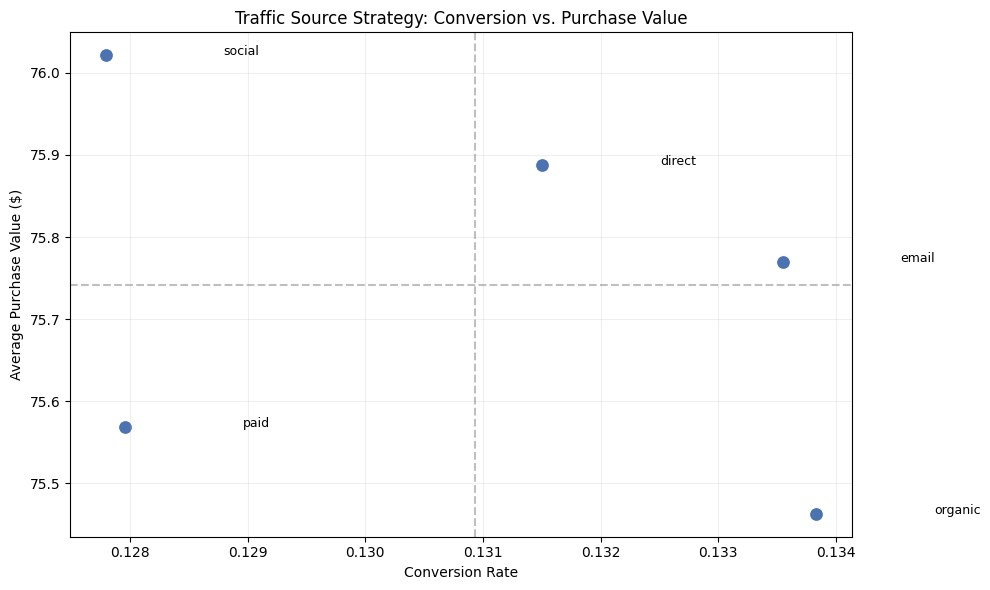

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=summary, x='conversion_rate', y='avg_purchase', s=100)

# FIX: Use .iloc to access values by their row position
for i in range(summary.shape[0]):
    plt.text(
        summary['conversion_rate'].iloc[i] + 0.001, 
        summary['avg_purchase'].iloc[i], 
        summary.index[i],
        fontsize=9
    )

# Add mean lines to create the Quadrants
plt.axvline(summary['conversion_rate'].mean(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(summary['avg_purchase'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.title('Traffic Source Strategy: Conversion vs. Purchase Value')
plt.xlabel('Conversion Rate')
plt.ylabel('Average Purchase Value ($)')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Traffic Source Insights:

Direct & Email (Top Right): These users are loyalists. They know what they want, they buy it, and they spend more. Strategy: Maintain and Reward.

Social (Top Left): These users browse high-end items but drop off before buying. Strategy: Use Retargeting ads to 'close the deal' and improve the checkout flow.

Organic (Bottom Right): These are 'Window Shoppers' who convert easily on low-cost items. Strategy: Implement 'Upsell' or 'Frequently Bought Together' prompts to raise their purchase value.

Paid (Bottom Left): This is 'Danger Zone.' We are paying for clicks that aren't spending much or converting well. Strategy: Audit your keywords— we might be bidding on terms that are too broad.

 While the correlation between conversion rate and purchase value is moderate (r = -0.38), the quadrant analysis highlights meaningful strategic differences across traffic sources. The clear separation of Social (High Value) from Organic (High Conversion) proves we need a multi-channel strategy.


Strategic Recommendations

Based on the combined marketing and statistical analysis, several strategic opportunities emerge:

1. Expand Email Marketing

Email generates the highest total revenue and attracts high-intent customers. Increasing segmentation and automation could drive additional growth.

2. Optimize the Conversion Funnel

With nearly 87% of sessions ending without a purchase, even small improvements in checkout flow or product discovery could significantly increase revenue.

3. Improve Revenue Quality in Paid Channels

Some channels generate high conversion but lower purchase values. Marketing investment should balance conversion efficiency with customer value.

4. Use Discounts Strategically

Discounts significantly reduce average transaction value and should be targeted toward acquisition campaigns rather than applied broadly.